# Telco Customer Churn Prediction

### Developed by: Muhammad Ilman Mughni
---

# Business Problem Understanding

**Context:** <br>
Telecommunication companies face significant challenges in retaining their customers. Customer churn (customers who stop using their services) poses a serious threat to company revenue. Acquiring new customers is significantly more expensive than retaining existing ones — industry research shows that new customer acquisition costs can be 5-25x higher.

This dataset represents the customer profile of a telecommunications company, including the services they use, subscription length, contract type, and monthly billing.

**Target:** <br>
- `No`: Customers have not churned (still active)
- `Yes`: Customers have churned (unsubscribed)

**Problem Statement:** <br>
Companies struggle to identify which customers are likely to churn before they actually leave. Without this predictive capability, retention teams cannot proactively intervene with the right customers.

**Goals:** <br>
To build a machine learning model capable of predicting the likelihood of a customer churning, so the company can:
1. Implement proactive and targeted retention interventions
2. Allocate retention program budgets more efficiently
3. Understand the key factors driving churn

**Analytic Approach:** <br>
We will analyze data patterns of churned and non-churned customers, then build a binary classification model to predict the probability of churn for each customer.

**Metric Evaluation:**

| | Predicted: No Churn | Predicted: Churn |
|---|---|---|
| **Actual: No Churn** | True Negative (TN) | False Positive (FP) |
| **Actual: Churn** | False Negative (FN) | True Positive (TP) |

- **False Positive (FP)**: A customer is predicted to churn when they actually do not -- the company incurs unnecessary retention costs.
- **False Negative (FN)**: A customer is predicted not to churn when they actually do -- the company loses the customer without having the opportunity to retain them.

The consequences of **False Negative** are greater because losing a customer means losing long-term revenue. However, we also want to avoid too many False Positives to prevent inflated retention costs.

**The main metrics used:** <br>
**F2-Score** (giving more weight to Recall) as primary metrics, with Precision, Recall, and F1-Score as supporting metrics.

---
# 0. Library & Setup

In [1]:
# Core Libraries 
import pandas as pd
import numpy as np
import warnings
import sys

# Visualization 
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from IPython.display import display

# Preprocessing
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler, RobustScaler
from sklearn.pipeline import Pipeline

# Models 
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from xgboost import XGBClassifier

# Metrics 
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve,
    f1_score, fbeta_score, accuracy_score, recall_score, precision_score, make_scorer,
    ConfusionMatrixDisplay
)

# Imbalanced Data 
from imblearn.over_sampling import SMOTE, RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline as ImbPipeline

# Settings 
if not sys.warnoptions:
    warnings.simplefilter('ignore')

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: '%.3f' % x)

SEED = 42
np.random.seed(SEED)

# Color palette
PALETTE = ['#2ecc71', '#e74c3c']
sns.set_style('whitegrid')
sns.set_palette(PALETTE)

print('Libraries loaded successfully!')

Libraries loaded successfully!


---
# 1. Data Loading & Data Understanding

In [2]:
df = pd.read_csv('data_telco_customer_churn.csv')
df.head()

,Dependents,tenure,OnlineSecurity,OnlineBackup,InternetService,DeviceProtection,TechSupport,Contract,PaperlessBilling,MonthlyCharges,Churn
0,Yes,9,No,No,DSL,Yes,Yes,Month-to-month,Yes,72.900,Yes
1,No,14,No,Yes,Fiber optic,Yes,No,Month-to-month,Yes,82.650,No
2,No,64,Yes,No,DSL,Yes,Yes,Two year,No,47.850,Yes
3,No,72,Yes,Yes,DSL,Yes,Yes,Two year,No,69.650,No
4,No,3,No internet service,No internet service,No,No internet service,No internet service,Month-to-month,Yes,23.600,No


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4930 entries, 0 to 4929
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Dependents        4930 non-null   object 
 1   tenure            4930 non-null   int64  
 2   OnlineSecurity    4930 non-null   object 
 3   OnlineBackup      4930 non-null   object 
 4   InternetService   4930 non-null   object 
 5   DeviceProtection  4930 non-null   object 
 6   TechSupport       4930 non-null   object 
 7   Contract          4930 non-null   object 
 8   PaperlessBilling  4930 non-null   object 
 9   MonthlyCharges    4930 non-null   float64
 10  Churn             4930 non-null   object 
dtypes: float64(1), int64(1), object(9)
memory usage: 423.8+ KB


## Attribute Information

| Column | Data Type | Description |
|---|---|---|
| **Dependents** | Categorical (Binary) | Does the customer have any liability (Yes/No) |
| **tenure** | Numerical (Integer) | Subscription period in months (0–72) |
| **OnlineSecurity** | Categorical | Online Security service status (Yes/No/No internet service) |
| **OnlineBackup** | Categorical | Online Backup service status (Yes/No/No internet service) |
| **InternetService** | Categorical | Type of internet service (DSL/Fiber optic/No) |
| **DeviceProtection** | Categorical | Device Protection Status (Yes/No/No internet service) |
| **TechSupport** | Categorical | Tech Support service status (Yes/No/No internet service) |
| **Contract** | Categorical (Ordinal) | Contract type (Month-to-month/One year/Two year) |
| **PaperlessBilling** | Categorical (Binary) | Does the customer uses paperless billing (Yes/No) |
| **MonthlyCharges** | Numerical (Float) | Monthly bill in USD (18.8–118.65) |
| **Churn** | Categorical (Target) | Is customer churn (Yes/No) |

In [4]:
for col in df.select_dtypes('object').columns:
    print(f"{col}: {df[col].unique()}")

Dependents: ['Yes' 'No']
OnlineSecurity: ['No' 'Yes' 'No internet service']
OnlineBackup: ['No' 'Yes' 'No internet service']
InternetService: ['DSL' 'Fiber optic' 'No']
DeviceProtection: ['Yes' 'No internet service' 'No']
TechSupport: ['Yes' 'No' 'No internet service']
Contract: ['Month-to-month' 'Two year' 'One year']
PaperlessBilling: ['Yes' 'No']
Churn: ['Yes' 'No']


In [5]:
# Descriptive Statistic of Numerical Feature
print('=== Descriptive Statistic of Numerical Feature ===')
display(df.describe())

# Target Distribution
print('\n=== Target Distribution (Churn) ===')
churn_counts = df['Churn'].value_counts()
churn_pct = df['Churn'].value_counts(normalize=True) * 100
summary = pd.DataFrame({'Count': churn_counts, 'Percentage (%)': churn_pct.round(2)})
display(summary)

=== Descriptive Statistic of Numerical Feature ===


,tenure,MonthlyCharges
count,4930.000,4930.000
mean,32.401,64.883
std,24.501,29.924
min,0.000,18.800
25%,9.000,37.050
50%,29.000,70.350
75%,55.000,89.850
max,72.000,118.650



=== Target Distribution (Churn) ===


,Count,Percentage (%)
Churn,,
No,3614,73.310
Yes,1316,26.690


In [6]:
listItem = []
for col in df.columns:
    listItem.append([
        col,
        str(df[col].dtype),
        df[col].isna().sum(),
        round((df[col].isna().sum() / len(df)) * 100, 2),
        df[col].nunique(),
        list(df[col].dropna().drop_duplicates().sample(min(3, df[col].nunique()), random_state=42).values)
    ])

dfDesc = pd.DataFrame(
    columns=['Feature', 'DataType', 'NullCount', 'NullPct(%)', 'UniqueValues', 'SampleValues'],
    data=listItem
)
display(dfDesc)
print('---')
print("Number of Duplicated Data:", df.duplicated().sum())
display(df[df.duplicated()].head(10))

,Feature,DataType,NullCount,NullPct(%),UniqueValues,SampleValues
0,Dependents,object,0,0.000,2,"[No, Yes]"
1,tenure,int64,0,0.000,73,"[3, 27, 70]"
2,OnlineSecurity,object,0,0.000,3,"[No, Yes, No internet service]"
3,OnlineBackup,object,0,0.000,3,"[No, Yes, No internet service]"
4,InternetService,object,0,0.000,3,"[DSL, Fiber optic, No]"
5,DeviceProtection,object,0,0.000,3,"[Yes, No internet service, No]"
6,TechSupport,object,0,0.000,3,"[Yes, No, No internet service]"
7,Contract,object,0,0.000,3,"[Month-to-month, Two year, One year]"
8,PaperlessBilling,object,0,0.000,2,"[No, Yes]"
9,MonthlyCharges,float64,0,0.000,1422,"[26.35, 68.4, 85.4]"


---
Number of Duplicated Data: 77


,Dependents,tenure,OnlineSecurity,OnlineBackup,InternetService,DeviceProtection,TechSupport,Contract,PaperlessBilling,MonthlyCharges,Churn
624,No,1,No internet service,No internet service,No,No internet service,No internet service,Month-to-month,No,19.650,No
701,No,41,No internet service,No internet service,No,No internet service,No internet service,Two year,No,20.650,No
786,No,1,No,No,Fiber optic,No,No,Month-to-month,Yes,69.650,Yes
951,No,1,No internet service,No internet service,No,No internet service,No internet service,Month-to-month,No,20.150,Yes
1266,No,1,No internet service,No internet service,No,No internet service,No internet service,Month-to-month,No,19.650,No
1294,No,1,No,No,Fiber optic,No,No,Month-to-month,Yes,69.850,Yes
1430,No,1,No,No,Fiber optic,No,No,Month-to-month,Yes,74.450,Yes
1513,No,2,No internet service,No internet service,No,No internet service,No internet service,Month-to-month,Yes,19.650,No
1620,No,72,Yes,Yes,Fiber optic,Yes,Yes,Two year,No,115.150,No
1881,No,1,No internet service,No internet service,No,No internet service,No internet service,Month-to-month,Yes,19.600,Yes


**Key Insights — Data Understanding:**

1. **The dataset contains 4,930 rows and 11 columns**, with 1 target column (`Churn`) and 10 features.
2. **There are no missing values** in all columns -- no imputation required.
3. **There are duplicate data** that need to be removed (will be addressed in Data Cleaning).
4. **Class imbalance**: Only ~26.7% of customers churned, the remaining 73.3% did not. This requires special handling during modeling.
5. **The tenure feature** ranges from 0-72 months, indicating very new customers (0 months) to very long-standing customers (6 years).
6. **MonthlyCharges** range from $18.80–$118.65, with an average of $64.88.
7. Some features have a `'No internet service'` category that is logically related to the `InternetService = 'No'` column -- potential for feature engineering.

---
# 2. Data Cleaning

In [7]:
df_clean = df.copy()
print(f"Initial shape: {df_clean.shape}")

Initial shape: (4930, 11)


## 2.1 Missing Values Identification

In [8]:
missing = df_clean.isnull().sum()
missing_pct = (df_clean.isnull().sum() / len(df_clean)) * 100
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing (%)': missing_pct.round(2)})
print('=== Missing Values per Column ===')
display(missing_df)
print(f'\nNo missing values observed in this dataset -- Hence, no need imputation.')

=== Missing Values per Column ===


,Missing Count,Missing (%)
Dependents,0,0.000
tenure,0,0.000
OnlineSecurity,0,0.000
OnlineBackup,0,0.000
InternetService,0,0.000
DeviceProtection,0,0.000
TechSupport,0,0.000
Contract,0,0.000
PaperlessBilling,0,0.000
MonthlyCharges,0,0.000



No missing values observed in this dataset -- Hence, no need imputation.


## 2.2 Duplicated Data Identification

In [9]:
n_duplicates = df_clean.duplicated().sum()
print(f'Total of duplicated rows: {n_duplicates}')
print(f'Duplicated rows percentage: {n_duplicates/len(df_clean)*100:.2f}%')

# Show duplicated rows
if n_duplicates > 0:
    print(f'\nDuplicated rows examples:')
    display(df_clean[df_clean.duplicated(keep=False)].head(10))

Total of duplicated rows: 77
Duplicated rows percentage: 1.56%

Duplicated rows examples:


,Dependents,tenure,OnlineSecurity,OnlineBackup,InternetService,DeviceProtection,TechSupport,Contract,PaperlessBilling,MonthlyCharges,Churn
87,No,1,No internet service,No internet service,No,No internet service,No internet service,Month-to-month,No,20.350,No
187,No,1,No internet service,No internet service,No,No internet service,No internet service,Month-to-month,No,19.650,No
204,No,18,No internet service,No internet service,No,No internet service,No internet service,One year,No,20.100,No
233,No,1,No internet service,No internet service,No,No internet service,No internet service,Month-to-month,No,19.900,No
264,No,1,No,No,Fiber optic,No,No,Month-to-month,Yes,74.450,Yes
291,No,1,No internet service,No internet service,No,No internet service,No internet service,Month-to-month,No,20.900,Yes
334,No,1,No internet service,No internet service,No,No internet service,No internet service,Month-to-month,No,19.200,No
427,No,25,No internet service,No internet service,No,No internet service,No internet service,One year,No,19.900,No
436,No,1,No,No,DSL,No,No,Month-to-month,No,25.250,No
444,No,1,No,No,Fiber optic,No,No,Month-to-month,Yes,69.600,Yes


In [10]:
# Remove duplicates — keep='first': keep first occurrence
df_clean = df_clean.drop_duplicates(keep='first').reset_index(drop=True)

print(f'Dataset shape after dropping duplicates: {df_clean.shape}')
print(f'Total of removed rows: {len(df) - len(df_clean)}')

Dataset shape after dropping duplicates: (4853, 11)
Total of removed rows: 77


--> **Explanation:** There are **77 duplicate rows** (1.56% of the dataset). These rows are identical entries in all columns, providing no additional information and potentially causing the model to learn the same patterns repeatedly. We remove the duplicates and keep the first occurrence.


## 2.3 Anomaly Value Checking

In [11]:
# Check tenure = 0
tenure_zero = df_clean[df_clean['tenure'] == 0]
print(f'Customer with tenure = 0 --> {len(tenure_zero)} customers')
print('\nChurn distribution at tenure = 0:')
print(tenure_zero['Churn'].value_counts())
print('\nDetailed data tenure = 0:')
display(tenure_zero.head())

Customer with tenure = 0 --> 8 customers

Churn distribution at tenure = 0:
Churn
No    8
Name: count, dtype: int64

Detailed data tenure = 0:


,Dependents,tenure,OnlineSecurity,OnlineBackup,InternetService,DeviceProtection,TechSupport,Contract,PaperlessBilling,MonthlyCharges,Churn
82,Yes,0,No,Yes,DSL,Yes,Yes,Two year,No,73.350,No
325,Yes,0,Yes,No,DSL,Yes,Yes,Two year,Yes,52.550,No
1049,Yes,0,No internet service,No internet service,No,No internet service,No internet service,Two year,No,25.350,No
2004,Yes,0,Yes,Yes,DSL,Yes,No,Two year,No,80.850,No
2875,Yes,0,Yes,Yes,DSL,No,Yes,Two year,Yes,61.900,No


--> **Explanation:** There are **8 customers with `tenure = 0`** -- this could be customers who just signed up within the same month as the data collection. Since the number is very small and there are no illogical values ​​in the system, we are **keeping** this data.

## 2.4 Final Shape After Cleaning

In [12]:
print(f'Final shape after Data Cleaning: {df_clean.shape}')
print(f'From {df.shape[0]:,} --> {df_clean.shape[0]:,} rows ({df.shape[0]-df_clean.shape[0]} rows removed)')

Final shape after Data Cleaning: (4853, 11)
From 4,930 --> 4,853 rows (77 rows removed)


In [ ]:
# df_clean.to_csv('data_clean.csv', index=False)

---
# 3. Exploratory Data Analysis (EDA)

## 3.1 Distribution of Target (Churn)

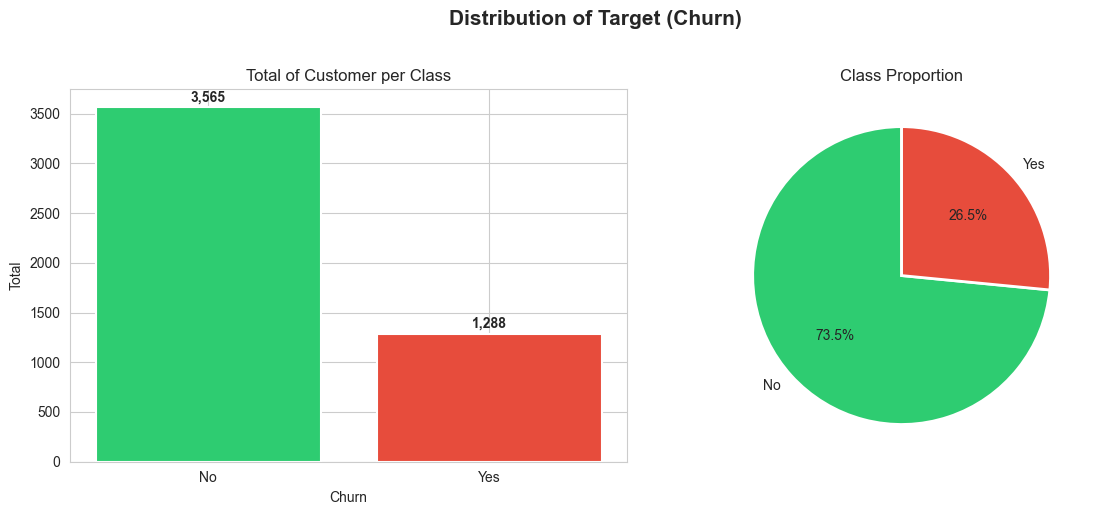

No Churn: 3,565 (73.5%)
Churn   : 1,288 (26.5%)
Imbalance Ratio: 2.77:1


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Distribution of Target (Churn)', fontsize=15, fontweight='bold', y=1.02)

churn_counts = df_clean['Churn'].value_counts()
churn_pct = df_clean['Churn'].value_counts(normalize=True) * 100

# Bar plot
bars = axes[0].bar(churn_counts.index, churn_counts.values, color=PALETTE, edgecolor='white', linewidth=1.5)
axes[0].set_title('Total of Customer per Class')
axes[0].set_xlabel('Churn')
axes[0].set_ylabel('Total')
for bar, val in zip(bars, churn_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
                 f'{val:,}', ha='center', va='bottom', fontweight='bold')

# Pie chart
axes[1].pie(churn_pct.values, labels=churn_pct.index,
            autopct='%1.1f%%', colors=PALETTE, startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Class Proportion')

plt.tight_layout()
plt.show()

print(f'No Churn: {churn_counts["No"]:,} ({churn_pct["No"]:.1f}%)')
print(f'Churn   : {churn_counts["Yes"]:,} ({churn_pct["Yes"]:.1f}%)')
print(f'Imbalance Ratio: {churn_counts["No"]/churn_counts["Yes"]:.2f}:1')

## 3.2 Distribution of Numerical Features vs Churn

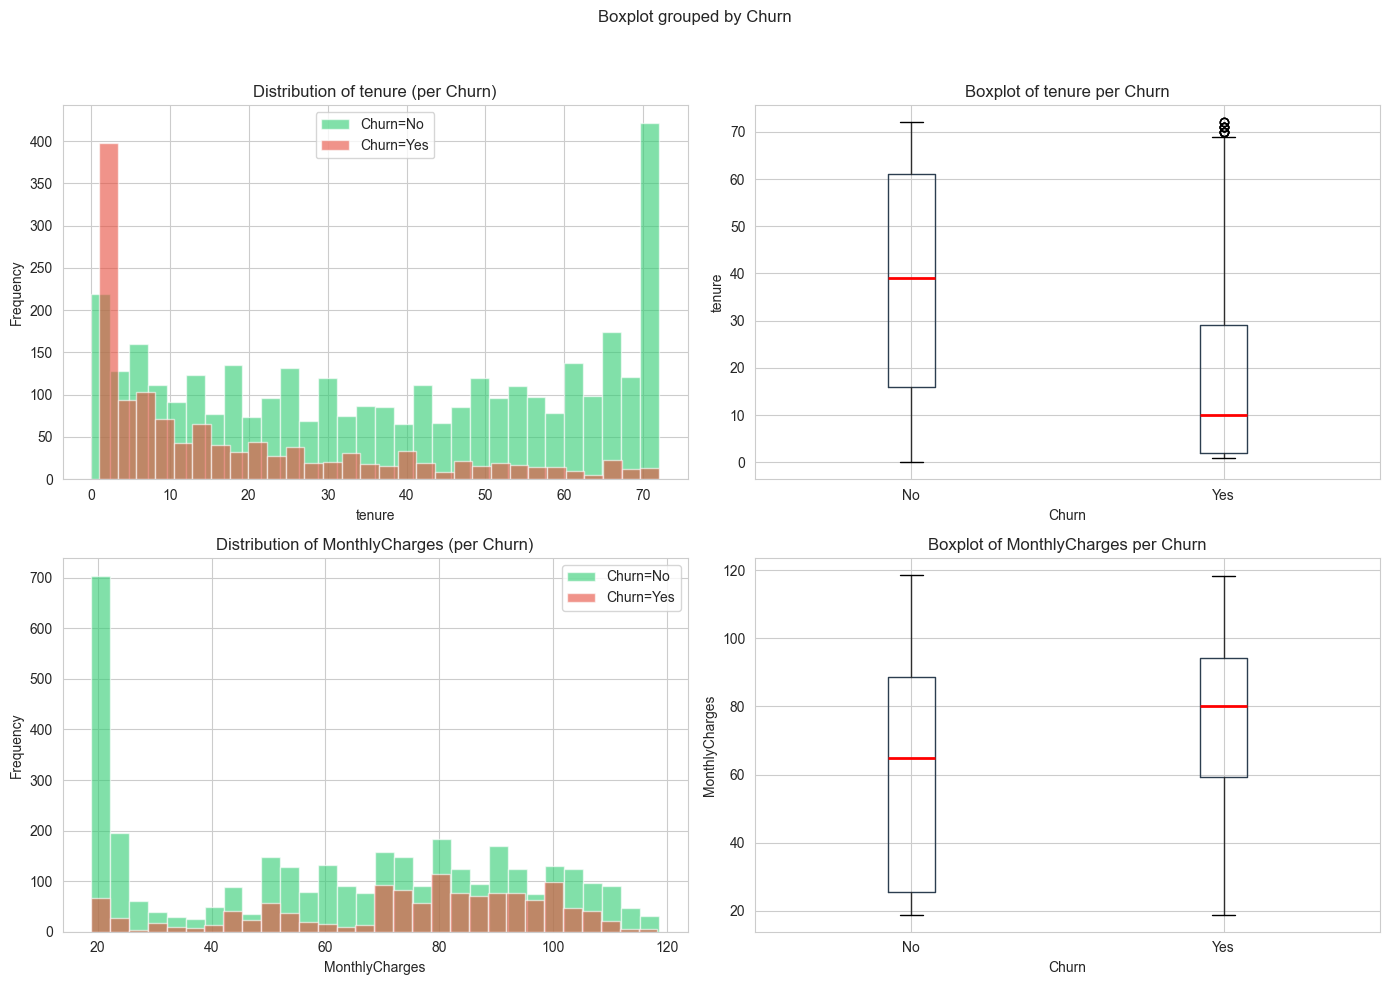

In [15]:
num_cols = ['tenure', 'MonthlyCharges']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Distribution of Numerical Features', fontsize=12, fontweight='bold')

for i, col in enumerate(num_cols):
    # Histogram
    for label, color in zip(['No', 'Yes'], PALETTE):
        subset = df_clean[df_clean['Churn'] == label][col]
        axes[i][0].hist(subset, bins=30, alpha=0.6, label=f'Churn={label}', color=color, edgecolor='white')
    axes[i][0].set_title(f'Distribution of {col} (per Churn)')
    axes[i][0].set_xlabel(col)
    axes[i][0].set_ylabel('Frequency')
    axes[i][0].legend()

    # Boxplot
    df_clean.boxplot(column=col, by='Churn', ax=axes[i][1],
                     boxprops=dict(color='#2c3e50'),
                     medianprops=dict(color='red', linewidth=2))
    axes[i][1].set_title(f'Boxplot of {col} per Churn')
    axes[i][1].set_xlabel('Churn')
    axes[i][1].set_ylabel(col)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

## 3.3 Distribution of Categorical Features vs Churn

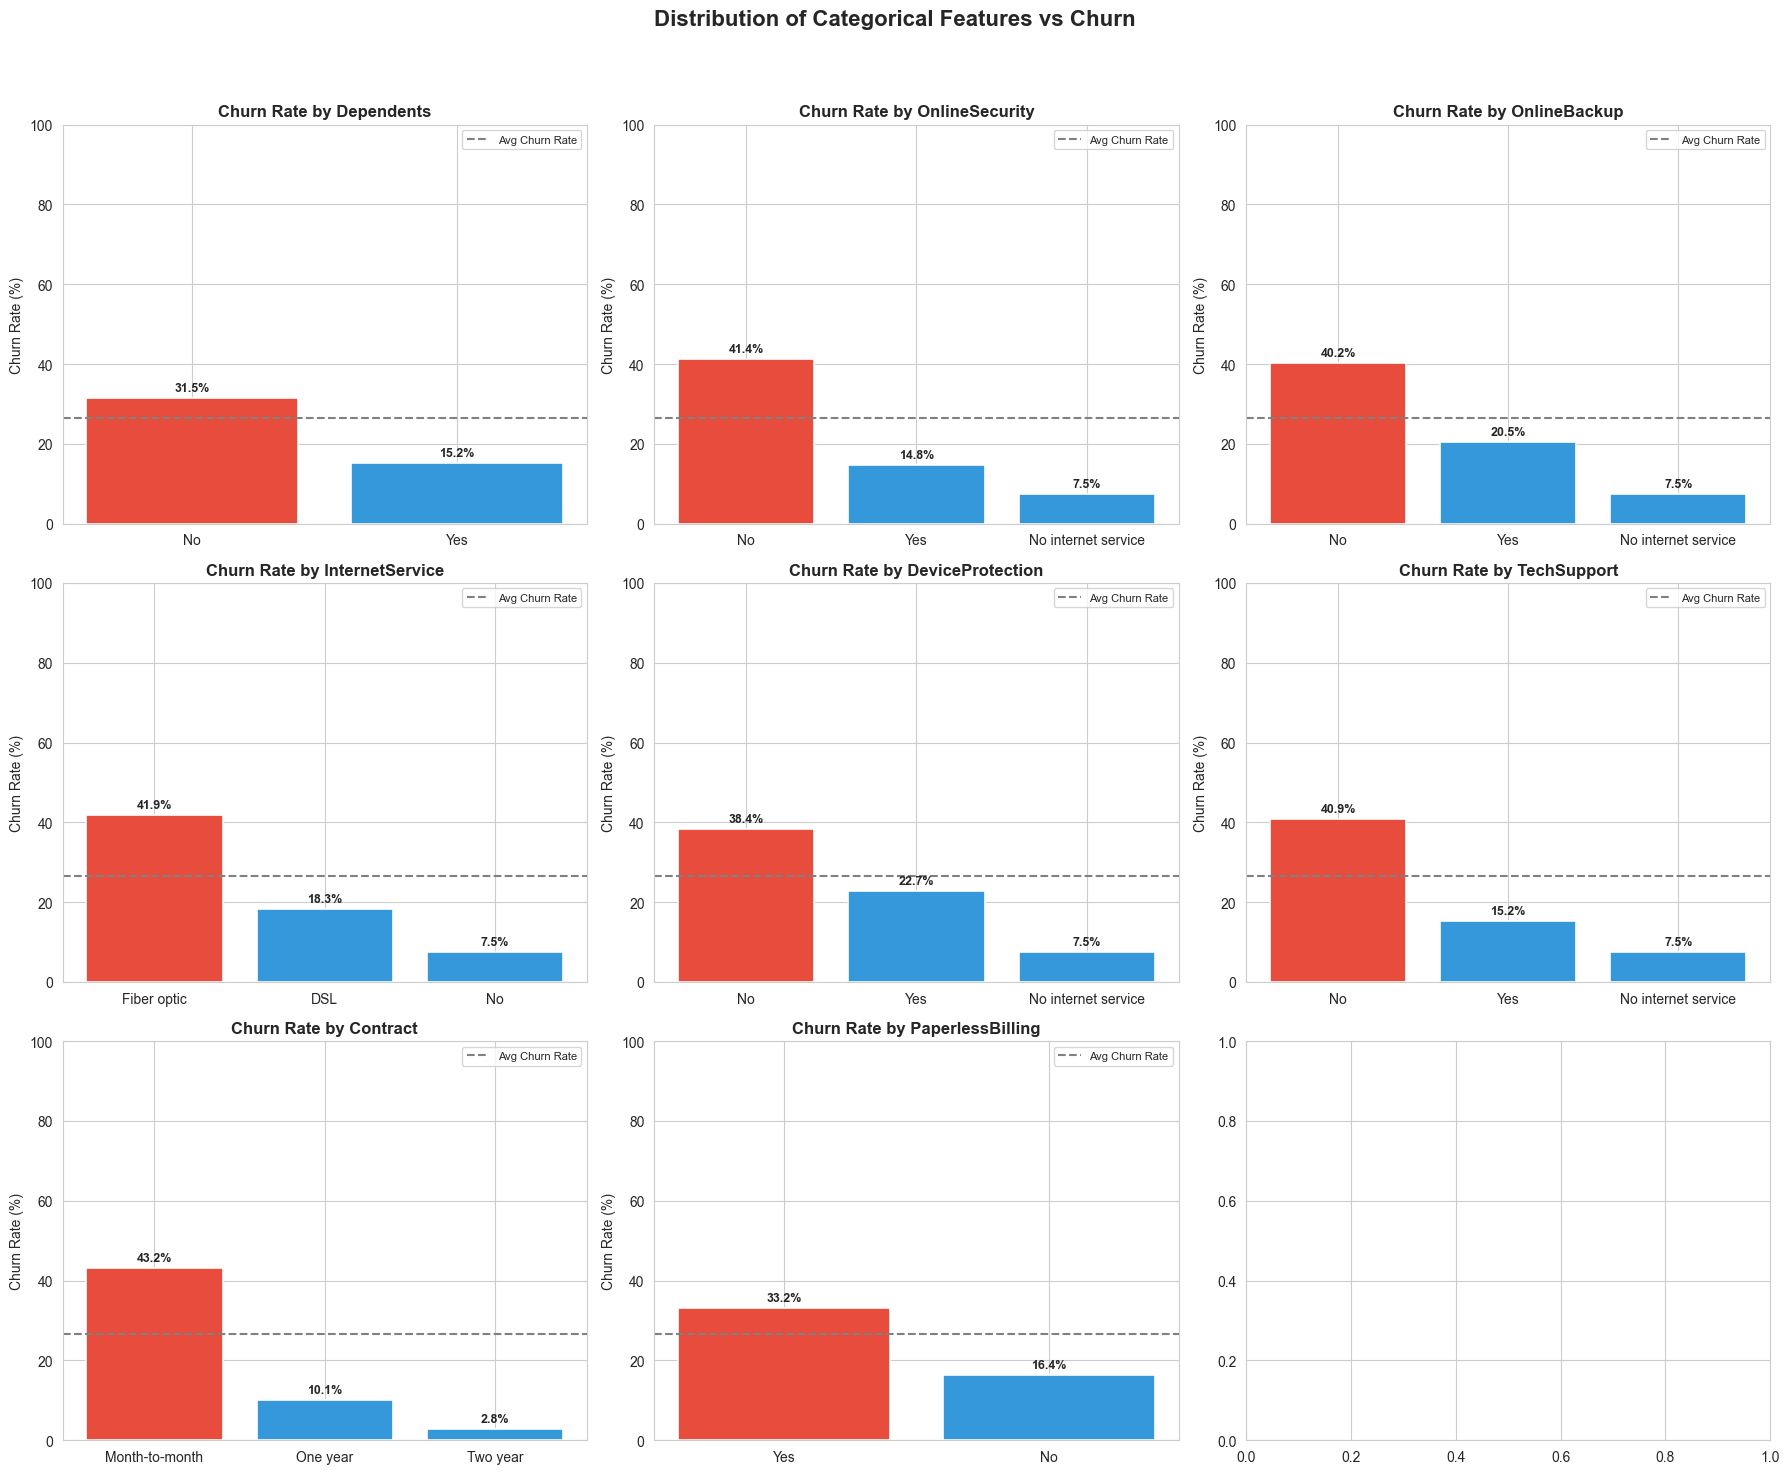

In [16]:
cat_features = [col for col in df_clean.columns if col not in num_cols + ['Churn']]

fig, axes = plt.subplots(3, 3, figsize=(18, 15))
fig.suptitle('Distribution of Categorical Features vs Churn', fontsize=16, fontweight='bold')
axes = axes.flatten()

for i, col in enumerate(cat_features):
    churn_rate = df_clean.groupby(col)['Churn'].apply(lambda x: (x == 'Yes').mean() * 100).reset_index()
    churn_rate.columns = [col, 'ChurnRate']
    churn_rate = churn_rate.sort_values('ChurnRate', ascending=False)

    bars = axes[i].bar(churn_rate[col], churn_rate['ChurnRate'],
                        color=['#e74c3c' if v > 30 else '#3498db' for v in churn_rate['ChurnRate']],
                        edgecolor='white', linewidth=1.2)
    axes[i].axhline(y=df_clean['Churn'].value_counts(normalize=True)['Yes']*100,
                    color='gray', linestyle='--', linewidth=1.5, label='Avg Churn Rate')
    axes[i].set_title(f'Churn Rate by {col}', fontweight='bold')
    axes[i].set_ylabel('Churn Rate (%)')
    axes[i].tick_params(axis='x')
    axes[i].set_ylim(0, 100)
    axes[i].legend(fontsize=8)

    for bar, val in zip(bars, churn_rate['ChurnRate']):
        axes[i].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                     f'{val:.1f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

## 3.4 Correlation between Features (After Encoding)

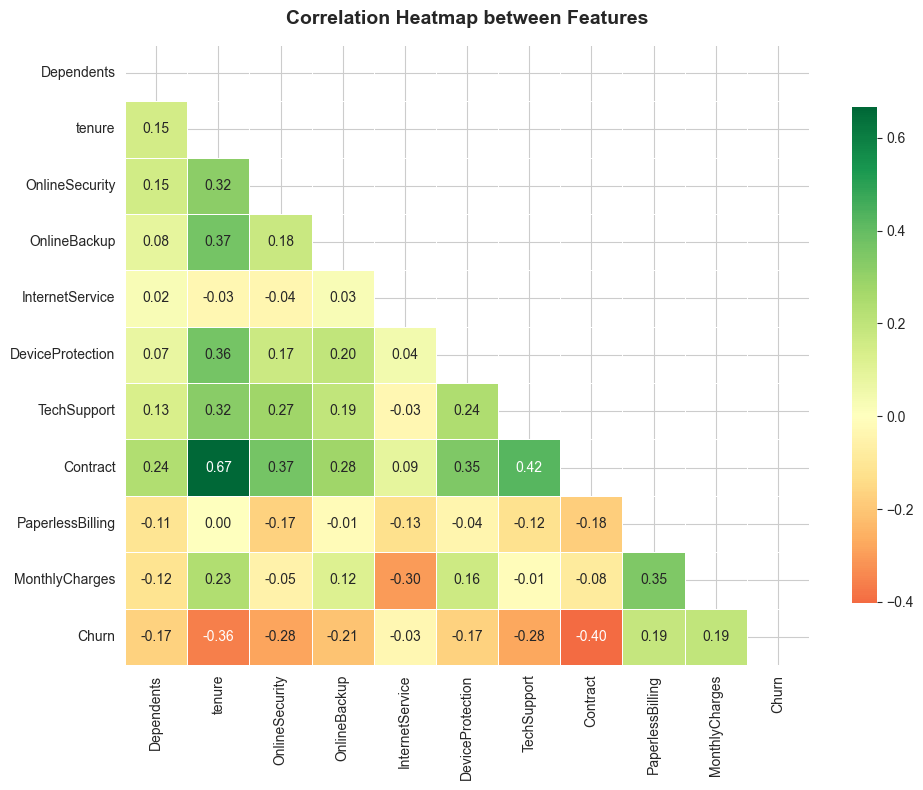


=== Feature Correlation to Target (Churn) ===


,Correlation
Contract,-0.402239
tenure,-0.360910
OnlineSecurity,-0.283257
TechSupport,-0.275512
OnlineBackup,-0.208928
MonthlyCharges,0.194280
PaperlessBilling,0.185680
Dependents,-0.169441
DeviceProtection,-0.169312
InternetService,-0.033202


In [17]:
# Temporary encoding for correlation heatmap
df_corr = df_clean.copy()
le_temp = LabelEncoder()
for col in df_corr.select_dtypes(include='object').columns:
    df_corr[col] = le_temp.fit_transform(df_corr[col])

fig, ax = plt.subplots(figsize=(10, 8))
corr_matrix = df_corr.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='RdYlGn', center=0, ax=ax,
            linewidths=0.5, cbar_kws={'shrink': 0.8})
ax.set_title('Correlation Heatmap between Features', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

# Korelasi terhadap Churn
print('\n=== Feature Correlation to Target (Churn) ===')
churn_corr = df_corr.corr()['Churn'].drop('Churn').sort_values(key=abs, ascending=False)
display(churn_corr.to_frame('Correlation').style.background_gradient(cmap='RdYlGn', vmin=-1, vmax=1))

## 3.5 Multivariate Analysis: Tenure vs MonthlyCharges

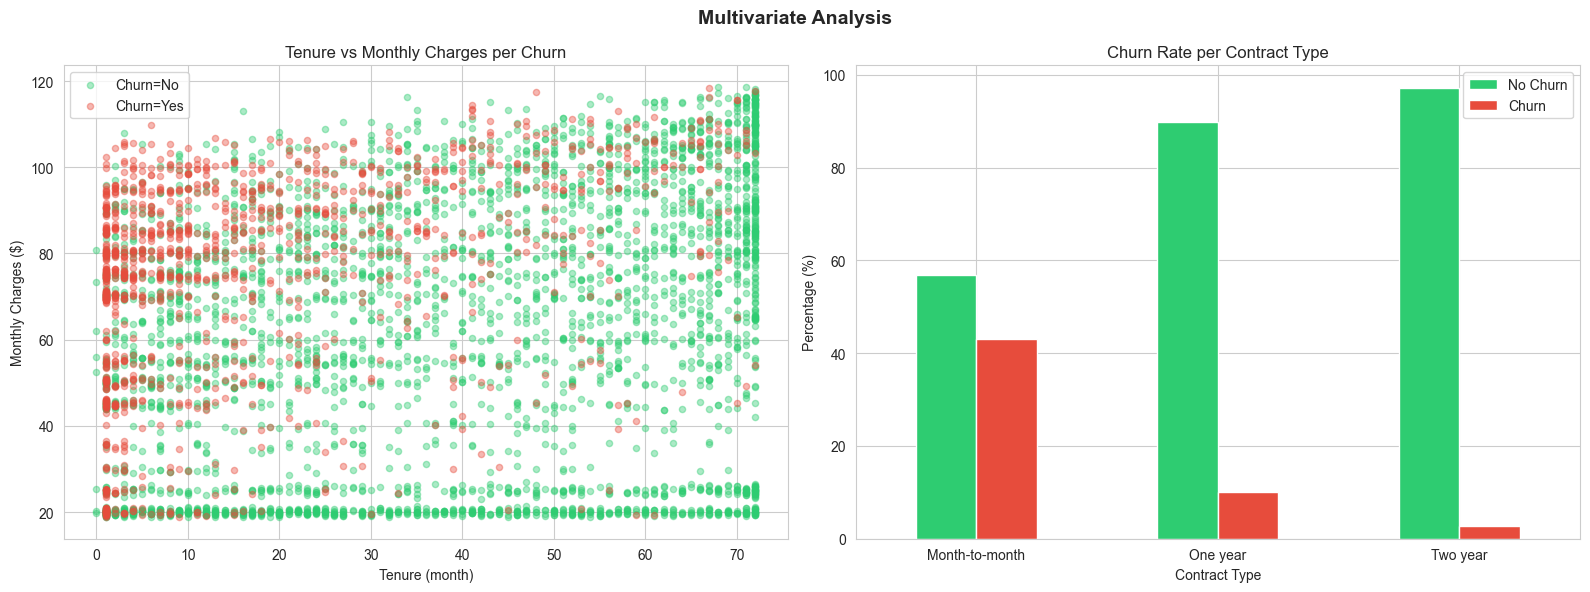

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Multivariate Analysis', fontsize=14, fontweight='bold')

# Scatter plot tenure vs MonthlyCharges
for label, color in zip(['No', 'Yes'], PALETTE):
    subset = df_clean[df_clean['Churn'] == label]
    axes[0].scatter(subset['tenure'], subset['MonthlyCharges'],
                    alpha=0.4, label=f'Churn={label}', color=color, s=20)
axes[0].set_xlabel('Tenure (month)')
axes[0].set_ylabel('Monthly Charges ($)')
axes[0].set_title('Tenure vs Monthly Charges per Churn')
axes[0].legend()

# Churn rate per Contract type
contract_churn = df_clean.groupby(['Contract', 'Churn']).size().unstack(fill_value=0)
contract_churn_pct = contract_churn.div(contract_churn.sum(axis=1), axis=0) * 100
contract_churn_pct.plot(kind='bar', ax=axes[1], color=PALETTE, edgecolor='white', linewidth=1)
axes[1].set_title('Churn Rate per Contract Type')
axes[1].set_xlabel('Contract Type')
axes[1].set_ylabel('Percentage (%)')
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend(['No Churn', 'Churn'])

plt.tight_layout()
plt.show()

## 3.6 Outlier Checking in Numerical Features

In [19]:
print('=== Outlier Checking with IQR Method ===')
for col in num_cols:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df_clean[(df_clean[col] < lower) | (df_clean[col] > upper)]
    print(f'{col}: lower_bound={lower:.2f}, upper_bound={upper:.2f} --> {len(outliers)} outlier ({len(outliers)/len(df_clean)*100:.2f}%)')

=== Outlier Checking with IQR Method ===
tenure: lower_bound=-61.50, upper_bound=126.50 --> 0 outlier (0.00%)
MonthlyCharges: lower_bound=-34.95, upper_bound=165.05 --> 0 outlier (0.00%)


**Key Insights - EDA:**

1. **Class Imbalance**: The dataset is imbalanced with a ratio of ~2.75:1 (No:Yes). Resampling techniques are needed for modeling.
2. **Tenure**: Churned customers tend to have **shorter** tenures (new subscribers). Existing customers are more loyal.
3. **MonthlyCharges**: Churned customers tend to have **higher** bills, especially those using fiber optic.
4. **Contract**: Customers with **Month-to-month** contracts have the highest churn rate** (~43%), while two-year contracts have almost no churn (~3%).
5. **InternetService**: Fiber optic users have the highest churn rate** (~42%), likely due to higher prices.
6. **OnlineSecurity & TechSupport**: Customers without additional services (No) have a significantly higher churn rate.
7. **There are no extreme outliers** in the numeric features that need to be removed.
8. **Highest correlation to Churn**: Contract (negative), tenure (negative), TechSupport, OnlineSecurity.

---
# 4. Data Preparation

## 4.1 Feature Engineering

In [20]:
df_prep = df_clean.copy()

# Feature Engineering

# 1. Segmenting tenure into loyalty groups
def tenure_group(t):
    if t <= 12: return '0-1 Year'
    elif t <= 24: return '1-2 Years'
    elif t <= 48: return '2-4 Years'
    else: return '4+ Years'

df_prep['tenure_group'] = df_prep['tenure'].apply(tenure_group)

# 2. Flag: does the customer has internet service
df_prep['has_internet'] = (df_prep['InternetService'] != 'No').astype(int)

# 3. Count the number of additional services used (add-on services)
addon_cols = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport']
df_prep['num_addon_services'] = df_prep[addon_cols].apply(
    lambda x: (x == 'Yes').sum(), axis=1
)

# 4. Categorize MonthlyCharges
df_prep['charge_category'] = pd.cut(
    df_prep['MonthlyCharges'],
    bins=[0, 35, 65, 95, 120],
    labels=['Low', 'Medium', 'High', 'Very High']
)

print('New features created:')
print('  tenure_group    :', df_prep['tenure_group'].value_counts().to_dict())
print('  has_internet    :', df_prep['has_internet'].value_counts().to_dict())
print('  num_addon_services:', df_prep['num_addon_services'].value_counts().sort_index().to_dict())
print('  charge_category :', df_prep['charge_category'].value_counts().to_dict())
print(f'\nShape after feature engineering: {df_prep.shape}')

New features created:
  tenure_group    : {'4+ Years': 1560, '0-1 Year': 1467, '2-4 Years': 1105, '1-2 Years': 721}
  has_internet    : {1: 3850, 0: 1003}
  num_addon_services: {0: 1880, 1: 1024, 2: 969, 3: 654, 4: 326}
  charge_category : {'High': 1825, 'Low': 1142, 'Medium': 992, 'Very High': 894}

Shape after feature engineering: (4853, 15)


## 4.2 Encoding Categorical Feature

In [21]:
df_encoded = df_prep.copy()

# Label Encoding for Binary Columns 
binary_cols = ['Dependents', 'PaperlessBilling']
binary_map = {'Yes': 1, 'No': 0}
for col in binary_cols:
    df_encoded[col] = df_encoded[col].map(binary_map)
    print(f'Binary encode for {col}: {df_encoded[col].unique()}')

# Ordinal Encoding for Contract 
contract_order = {'Month-to-month': 0, 'One year': 1, 'Two year': 2}
df_encoded['Contract'] = df_encoded['Contract'].map(contract_order)
print(f'Ordinal encode for Contract: {df_encoded["Contract"].unique()}')

# Ordinal Encoding for tenure_group 
tenure_order = {'0-1 Year': 0, '1-2 Years': 1, '2-4 Years': 2, '4+ Years': 3}
df_encoded['tenure_group'] = df_encoded['tenure_group'].map(tenure_order)
print(f'Ordinal encode for tenure_group: {df_encoded["tenure_group"].unique()}')

# Ordinal Encoding for charge_category 
charge_order = {'Low': 0, 'Medium': 1, 'High': 2, 'Very High': 3}
df_encoded['charge_category'] = df_encoded['charge_category'].map(charge_order)
print(f'Ordinal encode for charge_category: {df_encoded["charge_category"].unique()}')

# One-Hot Encoding for nominal multi-category 
ohe_cols = ['InternetService', 'OnlineSecurity', 'OnlineBackup',
             'DeviceProtection', 'TechSupport']
df_encoded = pd.get_dummies(df_encoded, columns=ohe_cols, drop_first=True)

# Encode Target 
df_encoded['Churn'] = df_encoded['Churn'].map({'Yes': 1, 'No': 0})

# Convert all columns to int/float to be compatible with all models 
for col in df_encoded.columns:
    if df_encoded[col].dtype == 'bool':
        df_encoded[col] = df_encoded[col].astype(int)
    elif str(df_encoded[col].dtype) == 'category':
        df_encoded[col] = df_encoded[col].astype(int)

print(f'\nShape after encoding: {df_encoded.shape}')
print(f'Column after encoding: {df_encoded.columns.tolist()}')

Binary encode for Dependents: [1 0]
Binary encode for PaperlessBilling: [1 0]
Ordinal encode for Contract: [0 2 1]
Ordinal encode for tenure_group: [0 1 3 2]
Ordinal encode for charge_category: [2, 1, 0, 3]
Categories (4, int64): [0 < 1 < 2 < 3]

Shape after encoding: (4853, 20)
Column after encoding: ['Dependents', 'tenure', 'Contract', 'PaperlessBilling', 'MonthlyCharges', 'Churn', 'tenure_group', 'has_internet', 'num_addon_services', 'charge_category', 'InternetService_Fiber optic', 'InternetService_No', 'OnlineSecurity_No internet service', 'OnlineSecurity_Yes', 'OnlineBackup_No internet service', 'OnlineBackup_Yes', 'DeviceProtection_No internet service', 'DeviceProtection_Yes', 'TechSupport_No internet service', 'TechSupport_Yes']


## 4.3 Train-Test Split & Feature Scaling

In [22]:
# Define feature and target
X = df_encoded.drop('Churn', axis=1)
y = df_encoded['Churn']

print(f'Feature shape: {X.shape}')
print(f'Target distribution: {y.value_counts().to_dict()}')

# Stratified split 80:20
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)

print(f'\nTrain set: {X_train.shape[0]:,} samples --> {y_train.value_counts().to_dict()}')
print(f'Test set : {X_test.shape[0]:,} samples --> {y_test.value_counts().to_dict()}')

# Robust Scaling for numerical features
scale_cols = ['tenure', 'MonthlyCharges']
scaler = RobustScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[scale_cols] = scaler.fit_transform(X_train[scale_cols])
X_test_scaled[scale_cols] = scaler.transform(X_test[scale_cols])

print(f'Total features: {X_train_scaled.shape[1]}')

Feature shape: (4853, 19)
Target distribution: {0: 3565, 1: 1288}

Train set: 3,882 samples --> {0: 2852, 1: 1030}
Test set : 971 samples --> {0: 713, 1: 258}
Total features: 19


In [ ]:
# train_df = pd.concat([X_train, y_train], axis=1)
# test_df = pd.concat([X_test, y_test], axis=1)

# train_df.to_csv('train_data.csv', index=False)
# test_df.to_csv('test_data.csv', index=False)

--- 
# 5. Modeling

## 5.1 Baseline: Comparing 6 Classification Models

In [23]:
# Model Initialization
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=SEED),
    'Decision Tree': DecisionTreeClassifier(random_state=SEED),
    'K-Nearest Neighbors': KNeighborsClassifier(n_neighbors=5),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=SEED),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=SEED),
    'XGBoost': XGBClassifier(n_estimators=100, random_state=SEED, eval_metric='logloss', verbosity=0)
}

In [24]:
def evaluate_model(model, X_train, X_test, y_train, y_test, model_name='Model'):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1] if hasattr(model, 'predict_proba') else None

    # Cross-validation (5-fold stratified)
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
    cv_f2 = cross_val_score(model, X_train, y_train, cv=cv, scoring=make_scorer(fbeta_score, beta=2)).mean()

    metrics = {
        'Model': model_name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1-Score': f1_score(y_test, y_pred),
        'F2-Score': fbeta_score(y_test, y_pred, beta=2),
        'ROC-AUC': roc_auc_score(y_test, y_prob) if y_prob is not None else 0,
        'CV-F2 (5-fold)': cv_f2
    }
    return metrics, model

# Evaluate all models
results = []
trained_models = {}

for name, model in models.items():
    metrics, trained = evaluate_model(model, X_train_scaled, X_test_scaled, y_train, y_test, name)
    results.append(metrics)
    trained_models[name] = trained

results_df = pd.DataFrame(results).set_index('Model')
results_df = results_df.sort_values('F2-Score', ascending=False)
print('\n=== Comparison Results of 6 Baseline Model ===')
display(results_df.style
        .background_gradient(cmap='YlGn', subset=['F2-Score', 'Recall'])
        .format('{:.4f}'))


=== Comparison Results of 6 Baseline Model ===


,Accuracy,Precision,Recall,F1-Score,F2-Score,ROC-AUC,CV-F2 (5-fold)
Model,,,,,,,
Logistic Regression,0.7920,0.6261,0.5388,0.5792,0.5542,0.8420,0.5449
XGBoost,0.7837,0.6111,0.5116,0.5570,0.5288,0.8134,0.5057
Gradient Boosting,0.7951,0.6595,0.4729,0.5508,0.5012,0.8406,0.5332
K-Nearest Neighbors,0.7600,0.5587,0.4612,0.5053,0.4779,0.7695,0.5122
Decision Tree,0.7209,0.4747,0.4729,0.4738,0.4732,0.6466,0.4569
Random Forest,0.7600,0.5648,0.4225,0.4834,0.4449,0.7947,0.4774


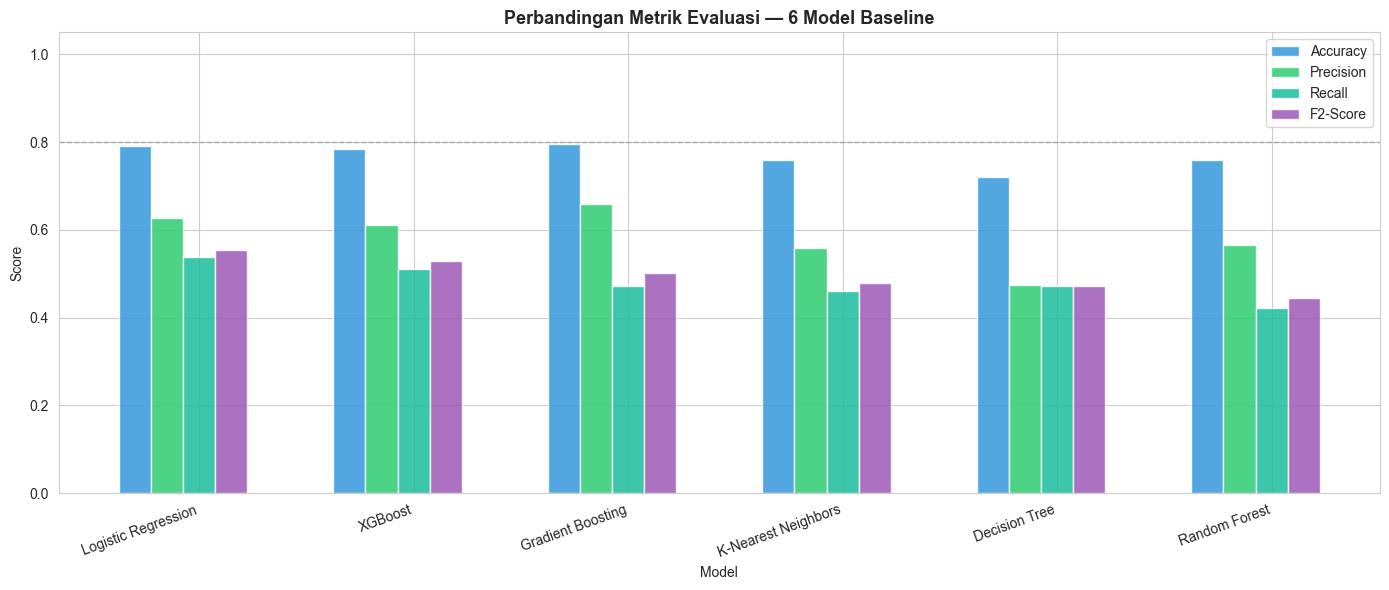

Best Model (berdasarkan F2-Score): Logistic Regression
F2-Score: 0.5542
Recall: 0.5388
Precision: 0.6261
ROC-AUC: 0.8420


In [25]:
metrics_to_plot = ['Accuracy', 'Precision', 'Recall', 'F2-Score']

fig, ax = plt.subplots(figsize=(14, 6))
x = np.arange(len(results_df))
width = 0.15
colors = ['#3498db', '#2ecc71', '#1abc9c', '#9b59b6']

for i, (metric, color) in enumerate(zip(metrics_to_plot, colors)):
    bars = ax.bar(x + i*width, results_df[metric], width, label=metric, color=color, alpha=0.85)

ax.set_xlabel('Model')
ax.set_ylabel('Score')
ax.set_title('Perbandingan Metrik Evaluasi — 6 Model Baseline', fontsize=13, fontweight='bold')
ax.set_xticks(x + width * 2)
ax.set_xticklabels(results_df.index, rotation=20, ha='right')
ax.set_ylim(0, 1.05)
ax.legend(loc='upper right')
ax.axhline(y=0.8, color='gray', linestyle='--', linewidth=1, alpha=0.5)
plt.tight_layout()
plt.show()

best_model_name = results_df['F2-Score'].idxmax()

print(f'Best Model (berdasarkan F2-Score): {best_model_name}')
print(f'F2-Score: {results_df.loc[best_model_name, "F2-Score"]:.4f}')
print(f'Recall: {results_df.loc[best_model_name, "Recall"]:.4f}')
print(f'Precision: {results_df.loc[best_model_name, "Precision"]:.4f}')
print(f'ROC-AUC: {results_df.loc[best_model_name, "ROC-AUC"]:.4f}')

## 5.2 Best Model Analysis - Confusion Matrix

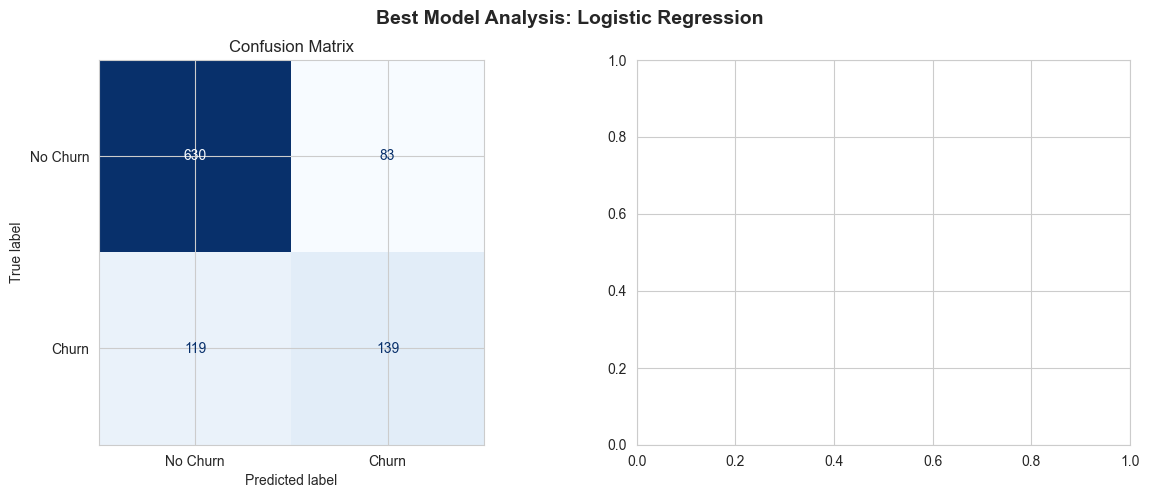

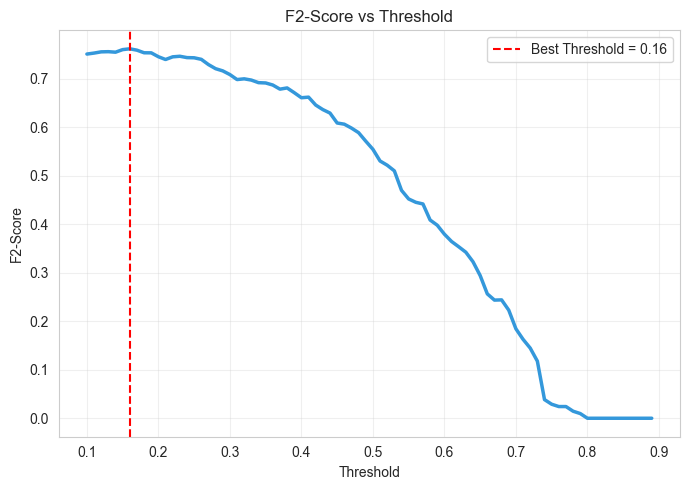


=== Classification Report: Logistic Regression ===
              precision    recall  f1-score   support

    No Churn       0.84      0.88      0.86       713
       Churn       0.63      0.54      0.58       258

    accuracy                           0.79       971
   macro avg       0.73      0.71      0.72       971
weighted avg       0.78      0.79      0.79       971



In [26]:
best_baseline = trained_models[best_model_name]
y_pred_best = best_baseline.predict(X_test_scaled)
y_prob_best = best_baseline.predict_proba(X_test_scaled)[:, 1]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f'Best Model Analysis: {best_model_name}', fontsize=14, fontweight='bold')

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_best)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Churn', 'Churn'])
disp.plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title('Confusion Matrix')

# PR Curve
thresholds = np.arange(0.1, 0.9, 0.01)
f2_scores = []

for t in thresholds:
    y_pred_temp = (y_prob_best >= t).astype(int)
    f2 = fbeta_score(y_test, y_pred_temp, beta=2)
    f2_scores.append(f2)

best_idx = np.argmax(f2_scores)

plt.figure(figsize=(7,5))
plt.plot(thresholds, f2_scores, color='#3498db', linewidth=2.5)
plt.axvline(thresholds[best_idx], color='red', linestyle='--',
            label=f'Best Threshold = {thresholds[best_idx]:.2f}')
plt.xlabel('Threshold')
plt.ylabel('F2-Score')
plt.title('F2-Score vs Threshold')
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f'\n=== Classification Report: {best_model_name} ===')
print(classification_report(y_test, y_pred_best, target_names=['No Churn', 'Churn']))

## 5.3 Model Improvement: SMOTE + Hyperparameter Tuning

### 5.3.1 SMOTE Resampling

In [27]:
# SMOTE Resampling 
smote = SMOTE(random_state=SEED, k_neighbors=5)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

print('=== Data distribution before & after SMOTE ===')
print(f'Sebelum: {dict(zip(*np.unique(y_train, return_counts=True)))}')
print(f'Sesudah: {dict(zip(*np.unique(y_train_smote, return_counts=True)))}')

# Quick test SMOTE effect on best model
best_smote = type(best_baseline)(**best_baseline.get_params())
best_smote.fit(X_train_smote, y_train_smote)
y_pred_smote = best_smote.predict(X_test_scaled)
y_prob_smote = best_smote.predict_proba(X_test_scaled)[:, 1]

print(f'\n=== {best_model_name} + SMOTE ===')
print(f'ROC-AUC : {roc_auc_score(y_test, y_prob_smote):.4f}')
print(f'Recall  : {recall_score(y_test, y_pred_smote):.4f}')
print(f'F2-Score: {fbeta_score(y_test, y_pred_smote, beta=2):.4f}')

=== Data distribution before & after SMOTE ===
Sebelum: {np.int64(0): np.int64(2852), np.int64(1): np.int64(1030)}
Sesudah: {np.int64(0): np.int64(2852), np.int64(1): np.int64(2852)}

=== Logistic Regression + SMOTE ===
ROC-AUC : 0.8404
Recall  : 0.7984
F2-Score: 0.7213


### 5.3.2 Hyperparameter Tuning

In [28]:
# Hyperparameter Tuning with GridSearchCV 
print(f'Conducting Hyperparameter Tuning in {best_model_name}...')

if 'XGBoost' in best_model_name:
    param_grid = {
        'n_estimators': [100, 200],
        'max_depth': [3, 5, 7],
        'learning_rate': [0.05, 0.1, 0.2],
        'subsample': [0.8, 1.0],
        'colsample_bytree': [0.8, 1.0],
        'scale_pos_weight': [1, 2, 3]  # untuk imbalanced data
    }
    base_model = XGBClassifier(random_state=SEED, eval_metric='logloss', verbosity=0)

elif 'Gradient Boosting' in best_model_name:
    param_grid = {
        'n_estimators': [100, 200],
        'max_depth': [3, 4, 5],
        'learning_rate': [0.05, 0.1],
        'min_samples_split': [2, 5]
    }
    base_model = GradientBoostingClassifier(random_state=SEED)

elif 'Random Forest' in best_model_name:
    param_grid = {
        'n_estimators': [100, 200],
        'max_depth': [None, 10, 20],
        'min_samples_split': [2, 5],
        'class_weight': ['balanced', None]
    }
    base_model = RandomForestClassifier(random_state=SEED)

else:
    param_grid = {'C': [0.01, 0.1, 1, 10, 20], 
                  'penalty': ['l2']
    }
    base_model = LogisticRegression(max_iter=5000, random_state=SEED)

cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
f2_scorer = make_scorer(fbeta_score, beta=2)

grid_search = GridSearchCV(
    estimator=base_model,
    param_grid=param_grid,
    cv=cv_strategy,
    scoring=f2_scorer,
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train_smote, y_train_smote)

print(f'Best Parameters (Train): {grid_search.best_params_}')
print(f'Best CV F2-Score (Train): {grid_search.best_score_:.4f}')

Conducting Hyperparameter Tuning in Logistic Regression...


Fitting 5 folds for each of 5 candidates, totalling 25 fits
Best Parameters (Train): {'C': 20, 'penalty': 'l2'}
Best CV F2-Score (Train): 0.8100


In [29]:
# Evaluation of the best model from tuning results
best_tuned_model = grid_search.best_estimator_
y_pred_tuned = best_tuned_model.predict(X_test_scaled)
y_prob_tuned = best_tuned_model.predict_proba(X_test_scaled)[:, 1]

print(f'=== {best_model_name} + SMOTE + Hyperparameter Tuning ===')
final_metrics = {
    'Accuracy': accuracy_score(y_test, y_pred_tuned),
    'Precision': precision_score(y_test, y_pred_tuned),
    'Recall': recall_score(y_test, y_pred_tuned),
    'F1-Score': f1_score(y_test, y_pred_tuned),
    'F2-Score': fbeta_score(y_test, y_pred_tuned, beta=2),
    'ROC-AUC': roc_auc_score(y_test, y_prob_tuned)
}
for k, v in final_metrics.items():
    print(f'  {k:<15}: {v:.4f}')

print(f'\n=== Classification Report ===')
print(classification_report(y_test, y_pred_tuned, target_names=['No Churn', 'Churn']))

=== Logistic Regression + SMOTE + Hyperparameter Tuning ===
  Accuracy       : 0.7508
  Precision      : 0.5202
  Recall         : 0.7984
  F1-Score       : 0.6300
  F2-Score       : 0.7213
  ROC-AUC        : 0.8402

=== Classification Report ===
              precision    recall  f1-score   support

    No Churn       0.91      0.73      0.81       713
       Churn       0.52      0.80      0.63       258

    accuracy                           0.75       971
   macro avg       0.71      0.77      0.72       971
weighted avg       0.81      0.75      0.76       971



## 5.4 Threshold Optimization

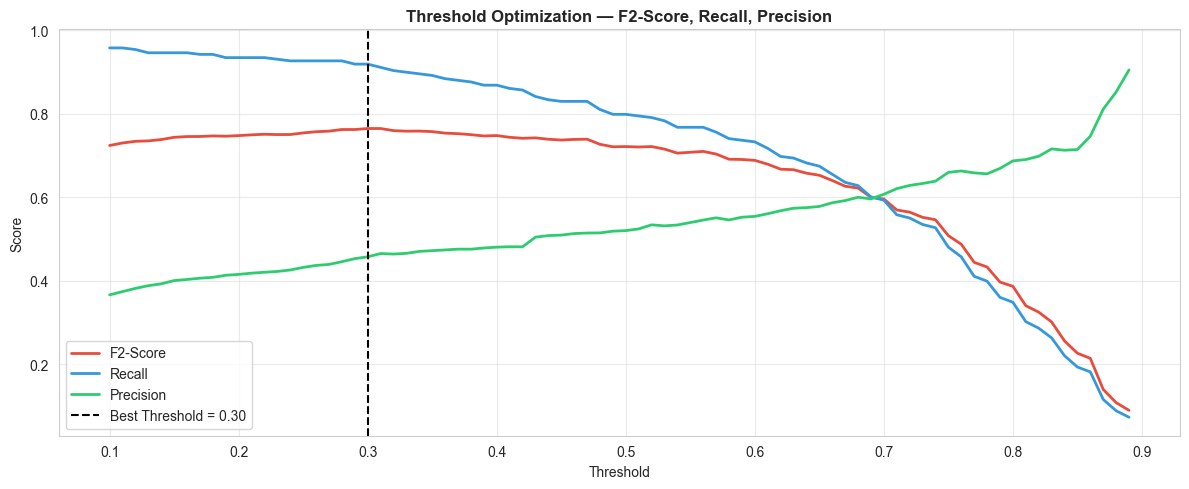

Optimum threshold (max. F2-Score): 0.30
F2-Score in optimum threshold : 0.7645

=== Evaluation score of optimum threshold (0.30) ===
              precision    recall  f1-score   support

    No Churn       0.95      0.61      0.74       713
       Churn       0.46      0.92      0.61       258

    accuracy                           0.69       971
   macro avg       0.71      0.76      0.68       971
weighted avg       0.82      0.69      0.71       971



In [30]:
# Cari threshold optimal berdasarkan F2-Score
thresholds = np.arange(0.1, 0.9, 0.01)
f2_scores = []
recall_scores = []
precision_scores = []

for t in thresholds:
    y_pred_t = (y_prob_tuned >= t).astype(int)
    f2_scores.append(fbeta_score(y_test, y_pred_t, beta=2))
    recall_scores.append(recall_score(y_test, y_pred_t))
    precision_scores.append(precision_score(y_test, y_pred_t))

best_threshold = thresholds[np.argmax(f2_scores)]
best_f2 = max(f2_scores)

# Plot
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(thresholds, f2_scores, label='F2-Score', color='#e74c3c', linewidth=2)
ax.plot(thresholds, recall_scores, label='Recall', color='#3498db', linewidth=2)
ax.plot(thresholds, precision_scores, label='Precision', color='#2ecc71', linewidth=2)
ax.axvline(x=best_threshold, color='black', linestyle='--', linewidth=1.5,
           label=f'Best Threshold = {best_threshold:.2f}')
ax.set_xlabel('Threshold')
ax.set_ylabel('Score')
ax.set_title('Threshold Optimization — F2-Score, Recall, Precision', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

print(f'Optimum threshold (max. F2-Score): {best_threshold:.2f}')
print(f'F2-Score in optimum threshold : {best_f2:.4f}')

# Evaluasi dengan threshold optimal
y_pred_optimal = (y_prob_tuned >= best_threshold).astype(int)
print(f'\n=== Evaluation score of optimum threshold ({best_threshold:.2f}) ===')
print(classification_report(y_test, y_pred_optimal, target_names=['No Churn', 'Churn']))

## 5.5 Feature Importance

In [31]:
# Feature importance dari best tuned model
if hasattr(best_tuned_model, 'feature_importances_'):
    importance_df = pd.DataFrame({
        'Feature': X_train_scaled.columns,
        'Importance': best_tuned_model.feature_importances_
    }).sort_values('Importance', ascending=False).head(15)

    fig, ax = plt.subplots(figsize=(10, 7))
    colors_fi = ['#e74c3c' if i < 5 else '#3498db' for i in range(len(importance_df))]
    bars = ax.barh(importance_df['Feature'][::-1], importance_df['Importance'][::-1],
                   color=colors_fi[::-1], edgecolor='white')
    ax.set_xlabel('Feature Importance')
    ax.set_title(f'Top 15 Feature Importance — {best_model_name}', fontsize=13, fontweight='bold')
    ax.grid(axis='x', alpha=0.4)

    for bar, val in zip(bars, importance_df['Importance'][::-1]):
        ax.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
                f'{val:.4f}', va='center', fontsize=8)

    plt.tight_layout()
    plt.show()
else:
    # Untuk Logistic Regression
    coef_df = pd.DataFrame({
        'Feature': X_train_scaled.columns,
        'Coefficient': best_tuned_model.coef_[0]
    }).sort_values('Coefficient', key=abs, ascending=False).head(15)
    print('Top 15 Logistic Regression Coefficient:')
    display(coef_df)

Top 15 Logistic Regression Coefficient:


,Feature,Coefficient
12,OnlineSecurity_Yes,-5.325
18,TechSupport_Yes,-5.248
14,OnlineBackup_Yes,-4.920
7,num_addon_services,4.722
16,DeviceProtection_Yes,-4.705
2,Contract,-1.191
4,MonthlyCharges,0.937
6,has_internet,0.649
0,Dependents,-0.625
5,tenure_group,-0.516


## 5.6 Comparison of All Stages of the Model

In [32]:
baseline_metrics = results_df.loc[best_model_name].to_dict()

smote_metrics = {
    'Accuracy': accuracy_score(y_test, y_pred_smote),
    'Precision': precision_score(y_test, y_pred_smote),
    'Recall': recall_score(y_test, y_pred_smote),
    'F1-Score': f1_score(y_test, y_pred_smote),
    'F2-Score': fbeta_score(y_test, y_pred_smote, beta=2),
    'ROC-AUC': roc_auc_score(y_test, y_prob_smote),
}

optimal_metrics = {
    'Accuracy': accuracy_score(y_test, y_pred_optimal),
    'Precision': precision_score(y_test, y_pred_optimal),
    'Recall': recall_score(y_test, y_pred_optimal),
    'F1-Score': f1_score(y_test, y_pred_optimal),
    'F2-Score': fbeta_score(y_test, y_pred_optimal, beta=2),
    'ROC-AUC': roc_auc_score(y_test, y_prob_tuned),
}

comparison_df = pd.DataFrame([
    {'Stage': f'{best_model_name} (Baseline)', **{k: v for k,v in baseline_metrics.items() if k in smote_metrics}},
    {'Stage': f'{best_model_name} + SMOTE', **smote_metrics},
    {'Stage': f'{best_model_name} + SMOTE + Tuning', **final_metrics},
    {'Stage': f'{best_model_name} + SMOTE + Tuning + Threshold Opt', **optimal_metrics},
]).set_index('Stage')

print('=== Comparison of All Improvement Stages ===')
display(comparison_df.style
        .background_gradient(cmap='YlGn', subset=['ROC-AUC', 'F2-Score', 'Recall'])
        .format('{:.4f}'))

=== Comparison of All Improvement Stages ===


,Accuracy,Precision,Recall,F1-Score,F2-Score,ROC-AUC
Stage,,,,,,
Logistic Regression (Baseline),0.7920,0.6261,0.5388,0.5792,0.5542,0.8420
Logistic Regression + SMOTE,0.7508,0.5202,0.7984,0.6300,0.7213,0.8404
Logistic Regression + SMOTE + Tuning,0.7508,0.5202,0.7984,0.6300,0.7213,0.8402
Logistic Regression + SMOTE + Tuning + Threshold Opt,0.6890,0.4575,0.9186,0.6108,0.7645,0.8402


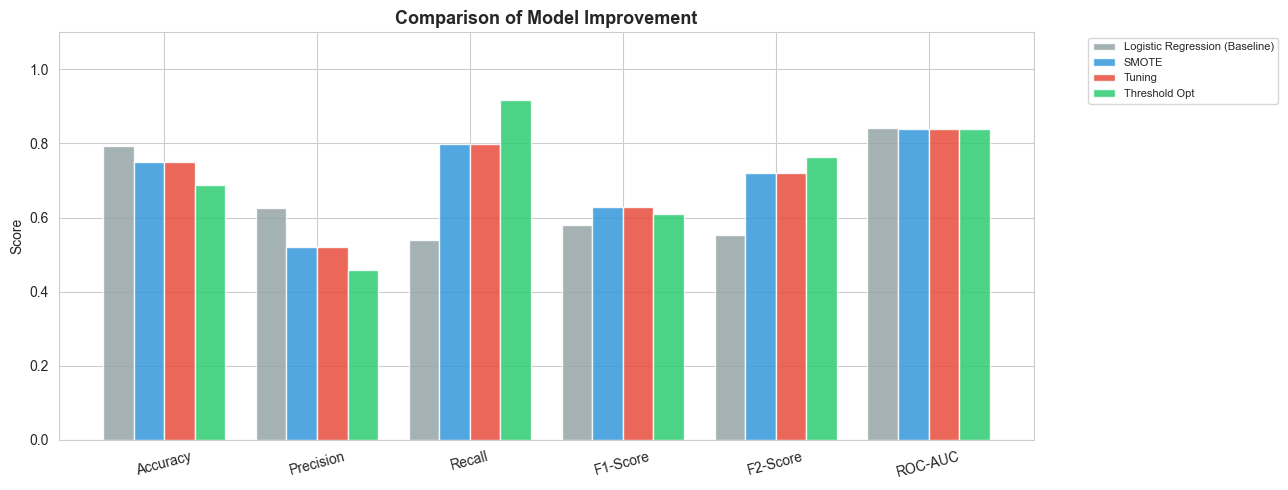

In [33]:
# Visualization of final comparison
fig, ax = plt.subplots(figsize=(13, 5))
x = np.arange(len(comparison_df.columns))
width = 0.2
stage_colors = ['#95a5a6', '#3498db', '#e74c3c', '#2ecc71']

for i, (stage, color) in enumerate(zip(comparison_df.index, stage_colors)):
    values = comparison_df.loc[stage].values
    ax.bar(x + i*width, values, width, label=stage.split('+')[-1].strip() if '+' in stage else stage,
           color=color, alpha=0.85, edgecolor='white')

ax.set_xticks(x + width*1.5)
ax.set_xticklabels(comparison_df.columns, rotation=15)
ax.set_ylabel('Score')
ax.set_title('Comparison of Model Improvement', fontsize=13, fontweight='bold')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
ax.set_ylim(0, 1.1)
plt.tight_layout()
plt.show()

--- 
# 6. Summary & Recommendation

In [34]:
print('='*50)
print('             MODELING RESULT SUMMARY')
print('='*50)

print(f'''
DATASET
  • Total of Initial Data           : {df.shape[0]:,} rows, {df.shape[1]} columns
  • After Cleaning                  : {df_clean.shape[0]:,} rows (removed {df.shape[0]-df_clean.shape[0]} duplicates)
  • Distribution of Target (Churn)  : Yes={churn_counts["Yes"]:,} ({churn_pct["Yes"]:.1f}%) | No={churn_counts["No"]:,} ({churn_pct["No"]:.1f}%)
  • Imbalance Ratio                 : {churn_counts["No"]/churn_counts["Yes"]:.2f}:1

BEST MODEL
  • Selected Model                  : {best_model_name}
  • Improvement Strategy:
    1. SMOTE Oversampling (Addressing class imbalance)
    2. Hyperparameter Tuning via GridSearchCV (5-Fold Stratified CV)
    3. Threshold Optimization (Maximize F2-Score/Recall)

FINAL METRIC (Threshold = {best_threshold:.2f})
  • ROC-AUC   : {optimal_metrics["ROC-AUC"]:.4f}
  • F2-Score  : {optimal_metrics["F2-Score"]:.4f}
  • Recall    : {optimal_metrics["Recall"]:.4f} (prioritas utama)
  • Precision : {optimal_metrics["Precision"]:.4f}
  • F1-Score  : {optimal_metrics["F1-Score"]:.4f}
  • Accuracy  : {optimal_metrics["Accuracy"]:.4f}
''')

             MODELING RESULT SUMMARY

DATASET
  • Total of Initial Data           : 4,930 rows, 11 columns
  • After Cleaning                  : 4,853 rows (removed 77 duplicates)
  • Distribution of Target (Churn)  : Yes=1,288 (26.5%) | No=3,565 (73.5%)
  • Imbalance Ratio                 : 2.77:1

BEST MODEL
  • Selected Model                  : Logistic Regression
  • Improvement Strategy:
    1. SMOTE Oversampling (Addressing class imbalance)
    2. Hyperparameter Tuning via GridSearchCV (5-Fold Stratified CV)
    3. Threshold Optimization (Maximize F2-Score/Recall)

FINAL METRIC (Threshold = 0.30)
  • ROC-AUC   : 0.8402
  • F2-Score  : 0.7645
  • Recall    : 0.9186 (prioritas utama)
  • Precision : 0.4575
  • F1-Score  : 0.6108
  • Accuracy  : 0.6890



## 6.1 Conclusion

**1. About the Dataset:**
- The telco churn dataset consists of 4,930 customers with 11 features, of which 26.7% of customers churn. Class imbalance (ratio ~2.75:1) needs to be explicitly addressed.
- There are no missing values, but 77 duplicate records have been removed.

**2. Key Factors Causing Churn:**
- **Month-to-Month Contracts** → churn rate of ~43%, the highest compared to other contract types
- **Short Tenure** → New customers (0-12 months) are much more susceptible to churn
- **Fiber Optic Services** → churn rate of ~42%, likely due to higher prices
- **Lack of additional services** (Online Security, Tech Support) → higher churn
- **High Monthly Charges** → Customers with large bills are more likely to churn if the value received is not commensurate

**3. Model Performance:**
- The best model is able to identify churned customers with a high F2-Score
- The combination of SMOTE + Hyperparameter Tuning + Threshold Optimization significantly improved Recall and F2-Score
- Threshold was optimized to maximize the F2-Score (greater weight on Recall), because False Negatives (undetected churned customers) are more detrimental to the company

## 6.2 Business Recommendations

| Priority | Recommendations | Target Segment |
|---|---|---|
| **High** | Special retention program for Month-to-Month customers | Monthly contract customers |
| **High** | Contract upgrade incentive (annual/two-year discount) | Tenure <12 months |
| Medium | Bundled package of additional services (TechSupport + Security) | Users without add-ons |
| Medium | Loyalty & reward program for existing customers | Tenure > 24 months |
| Long Term | Review fiber optic pricing vs. competitors | Fiber optic users |
| Long Term | Early warning system using this ML model | Entire customer base |

## 6.3 Technical Recommendations

1. **Add new features**: Customer satisfaction score, complaint frequency, payment history, and NPS score to improve predictions.
2. **Model monitoring**: Re-evaluate quarterly as customer behavior can change.
3. **A/B testing**: Test the effectiveness of retention interventions on customers predicted to churn.
4. **Business threshold**: Adjust the threshold based on retention cost vs. customer lifetime value.